# ECOWAS Border Intelligence Analytics Platform (EBIAP)

# Executive KPI Dashboard and Performance Reporting

## Impact Assessment of Simulated Regional Trade Diversion Following the AES Countries' Withdrawal from ECOWAS

### Case Study: Tsamiya–Kamba Transit Corridor

---

# Project Objective

This notebook develops executive-level Key Performance Indicators (KPIs) and performance summaries from the simulated ECOWAS border trade dataset.

The objective is to transform transaction-level data into high-level metrics that support strategic decision-making, performance monitoring, and operational planning.

---

# Business Problem

Senior decision-makers require concise, reliable, and timely indicators rather than raw transaction data.

This notebook demonstrates how data analytics can be used to generate executive dashboards that summarize border performance, customs revenue, operational efficiency, inspection outcomes, and security risks.

---

# Expected Outcomes

Upon completion, readers will be able to:

- Calculate executive KPIs.
- Build management summary tables.
- Identify operational trends.
- Generate dashboard-ready datasets.
- Export reports for Power BI and Streamlit.

In [18]:
# ============================================================
# Chapter 1 - Import Libraries
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [19]:
# ============================================================
# Chapter 2 - Load Dataset
# ============================================================

df = pd.read_csv("trade_diversion_transactions.csv")

print(df.shape)

df.head()

(100000, 20)


,Transaction_ID,Transaction_Date,Period,Origin_Country,Entry_Country,Destination_Country,Border_Post,Commodity,Vehicle_Type,Cargo_Weight_kg,Trade_Value_USD,Customs_Duty_USD,Revenue_Collected_USD,Queue_Length,Processing_Time_Minutes,Inspection_Result,Smuggling_Risk,Security_Incident,Scanner_Status,Border_Efficiency_Score
0,TRX0000001,2025-08-02,After Diversion,Togo,Cape Verde,Niger,Praia Port,Vehicles,Heavy Truck,23091.78,70960.57,9435.26,9791.44,17,25.9,Passed,Medium,No,Unavailable,98.0
1,TRX0000002,2022-08-17,Before Diversion,Nigeria,Togo,Niger,Kodjoviakope,Livestock,Heavy Truck,16533.94,63340.83,11608.49,11799.07,22,48.0,Passed,Low,No,Unavailable,82.3
2,TRX0000003,2022-02-21,Before Diversion,Benin,Benin,Niger,Hillacondji,Vehicles,Passenger Bus,943.86,13943.07,2766.44,2833.49,25,46.5,Passed,Medium,No,Unavailable,76.8
3,TRX0000004,2023-07-18,Before Diversion,Benin,Sierra Leone,Nigeria,Gbalamuya,Petroleum,Heavy Truck,18142.28,83276.36,13714.69,13775.83,6,20.5,Passed,Medium,No,Available,95.3
4,TRX0000005,2023-05-17,Before Diversion,Benin,Mali,Nigeria,Gogui,Vehicles,Heavy Truck,19017.79,62190.16,10388.67,10554.40,26,54.9,Passed,Low,No,Available,79.7


# Executive Key Performance Indicators (KPIs)

Calculate the primary indicators that would typically appear on an executive dashboard.

In [20]:
# ============================================================
# Chapter 3 - Executive KPI Summary
# ============================================================

kpis = {

    "Total Transactions":

        len(df),

    "Total Trade Value (USD)":

        df["Trade_Value_USD"].sum(),

    "Total Revenue Collected (USD)":

        df["Revenue_Collected_USD"].sum(),

    "Average Queue Length":

        df["Queue_Length"].mean(),

    "Average Processing Time (Minutes)":

        df["Processing_Time_Minutes"].mean(),

    "Average Border Efficiency Score":

        df["Border_Efficiency_Score"].mean()

}

kpi_summary = pd.DataFrame(

    kpis.items(),

    columns=["KPI", "Value"]

)

kpi_summary

,KPI,Value
0,Total Transactions,1.000000e+05
1,Total Trade Value (USD),5.329759e+09
2,Total Revenue Collected (USD),6.859825e+08
3,Average Queue Length,3.024694e+01
4,Average Processing Time (Minutes),5.432381e+01
5,Average Border Efficiency Score,7.852870e+01


# Executive KPI Dashboard

Visualize the executive performance indicators using a horizontal bar chart.

This visualization provides a quick overview of the relative magnitude of each KPI.

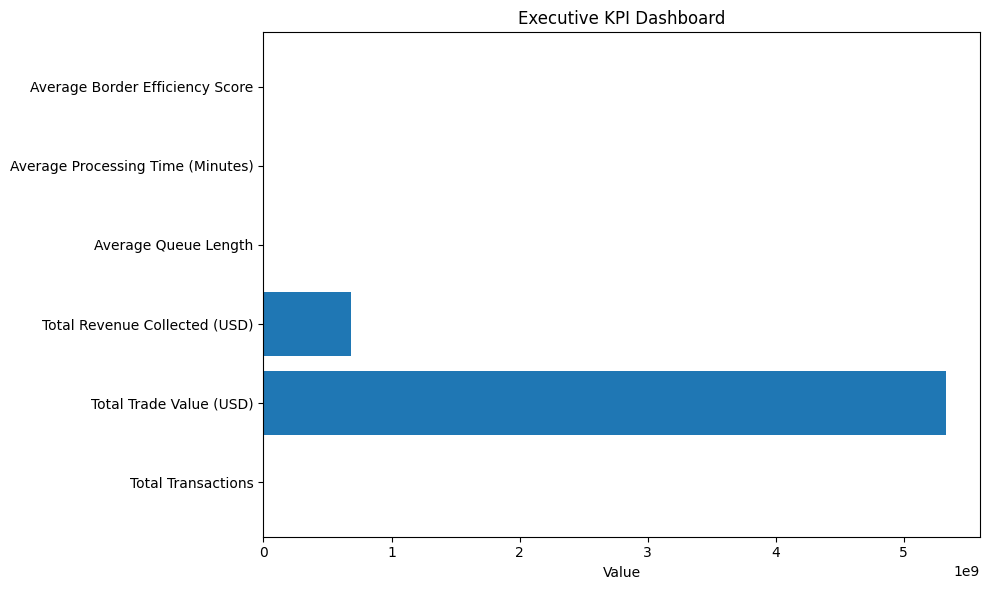

In [21]:
# ============================================================
# Chapter 4 - Executive KPI Visualization
# ============================================================

plt.figure(figsize=(10,6))

plt.barh(

    kpi_summary["KPI"],

    kpi_summary["Value"]

)

plt.title("Executive KPI Dashboard")

plt.xlabel("Value")

plt.tight_layout()

plt.show()

# Revenue by Border Post

Identify the border posts generating the highest customs revenue.

This analysis supports resource allocation and operational planning.

In [22]:
# ============================================================
# Chapter 5 - Revenue by Border Post
# ============================================================

revenue_border = (

    df.groupby("Border_Post")

    ["Revenue_Collected_USD"]

    .sum()

    .sort_values(

        ascending=False

    )

)

revenue_border

,Revenue_Collected_USD
Border_Post,
Malanville,45736299.53
Hillacondji,45471352.72
Tsamiya,43904800.29
Kodjoviakope,42272743.73
Cinkanse,37720302.83
Gaya,37357217.26
Konni,37067911.70
Gogui,37039457.22
Kidira,35005284.17


# Top Revenue-Generating Border Posts

This visualization identifies the ten border posts that generated the highest customs revenue during the study period.

Understanding revenue concentration assists policymakers in prioritizing infrastructure investment, staffing, and customs modernization initiatives.

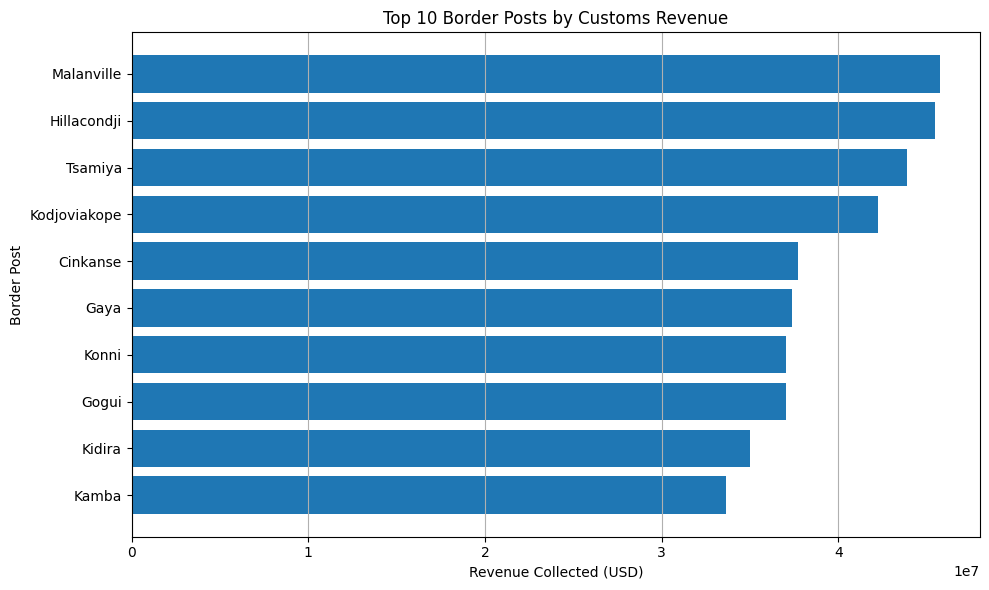

In [23]:
# ============================================================
# Chapter 6 - Top 10 Revenue Border Posts
# ============================================================

top10_revenue = (

    revenue_border

    .head(10)

)

plt.figure(figsize=(10,6))

plt.barh(

    top10_revenue.index,

    top10_revenue.values

)

plt.title("Top 10 Border Posts by Customs Revenue")

plt.xlabel("Revenue Collected (USD)")

plt.ylabel("Border Post")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.tight_layout()

plt.show()

# Revenue by Commodity

This analysis identifies the commodities contributing the largest share of customs revenue.

Commodity-level analysis supports trade policy evaluation, tariff review, and operational planning.

In [24]:
# ============================================================
# Chapter 7 - Revenue by Commodity
# ============================================================

commodity_revenue = (

    df.groupby("Commodity")

    ["Revenue_Collected_USD"]

    .sum()

    .sort_values(

        ascending=False

    )

)

commodity_revenue

,Revenue_Collected_USD
Commodity,
Rice,1.109856e+08
Petroleum,9.575366e+07
Construction Materials,7.453293e+07
Electronics,6.930176e+07
Textiles,6.235231e+07
Vehicles,6.225603e+07
Livestock,6.220152e+07
Pharmaceuticals,6.107939e+07
Agricultural Produce,5.333761e+07


# Commodity Revenue Distribution

Visualize customs revenue generated by each commodity category.

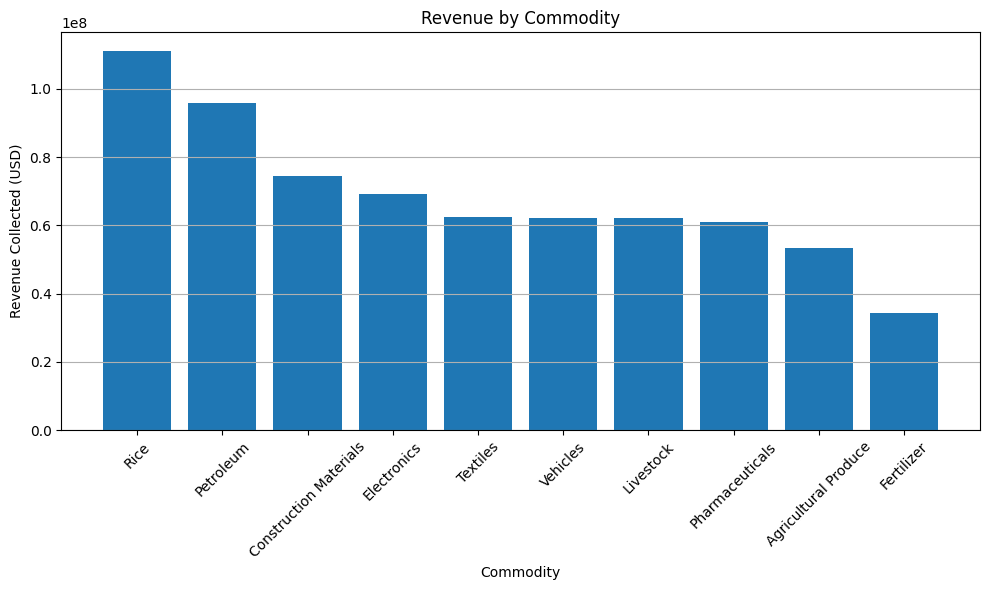

In [25]:
# ============================================================
# Chapter 8 - Commodity Revenue Chart
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(

    commodity_revenue.index,

    commodity_revenue.values

)

plt.title("Revenue by Commodity")

plt.xlabel("Commodity")

plt.ylabel("Revenue Collected (USD)")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# Border Efficiency Ranking

Border efficiency scores provide an indication of operational performance at each border post.

Higher scores represent more efficient processing of cross-border transactions.

In [26]:
# ============================================================
# Chapter 9 - Border Efficiency Ranking
# ============================================================

efficiency_rank = (

    df.groupby("Border_Post")

    ["Border_Efficiency_Score"]

    .mean()

    .sort_values(

        ascending=False

    )

)

efficiency_rank

,Border_Efficiency_Score
Border_Post,
Illela,83.563012
Sao Domingos,83.402660
Noe,83.372809
Amdallai,83.338568
Paga,83.330409
Kouremale,83.315744
Konni,83.310063
Gaya,83.297377
Elubo,83.246489


# Border Efficiency Comparison

Compare the average operational efficiency of all border posts.

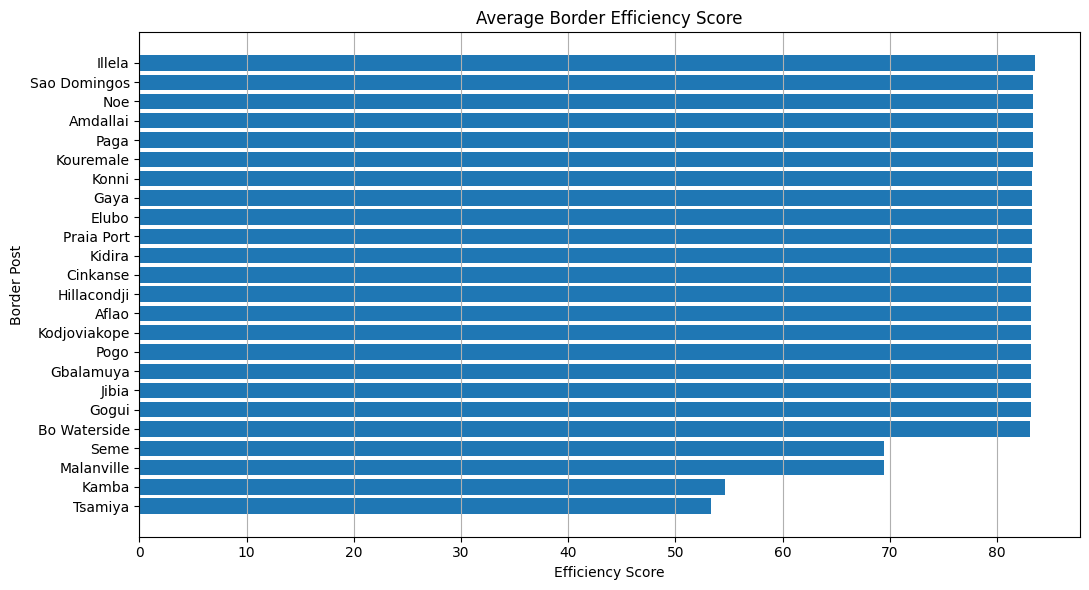

In [27]:
# ============================================================
# Chapter 10 - Border Efficiency Chart
# ============================================================

plt.figure(figsize=(11,6))

plt.barh(

    efficiency_rank.index,

    efficiency_rank.values

)

plt.title("Average Border Efficiency Score")

plt.xlabel("Efficiency Score")

plt.ylabel("Border Post")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.tight_layout()

plt.show()

# Inspection Performance

Evaluate the proportion of transactions that passed or failed inspection.

Inspection outcomes provide insight into operational effectiveness and compliance monitoring.

In [28]:
# ============================================================
# Chapter 11 - Inspection Performance
# ============================================================

inspection_summary = (

    df["Inspection_Result"]

    .value_counts()

)

inspection_summary

,count
Inspection_Result,
Passed,91159
Failed,8841


# Inspection Outcome Distribution

Visualize the distribution of inspection outcomes.

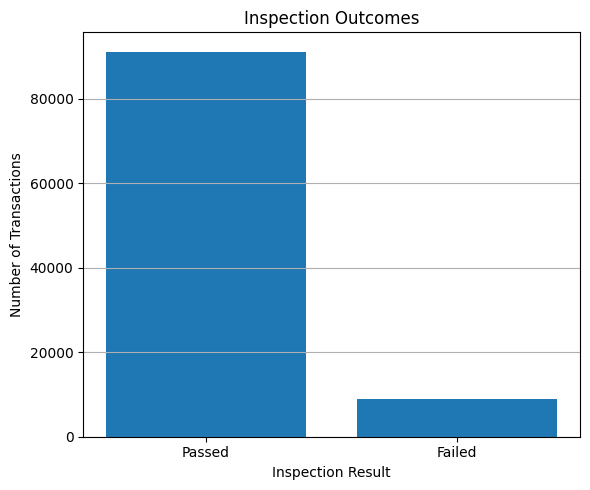

In [29]:
# ============================================================
# Chapter 12 - Inspection Performance Chart
# ============================================================

plt.figure(figsize=(6,5))

plt.bar(

    inspection_summary.index,

    inspection_summary.values

)

plt.title("Inspection Outcomes")

plt.xlabel("Inspection Result")

plt.ylabel("Number of Transactions")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# Security Incident Analysis

Security incidents represent operational events that may require intervention from border management agencies.

This section summarizes the frequency of reported security incidents within the simulated trade environment.

In [30]:
# ============================================================
# Chapter 13 - Security Incident Analysis
# ============================================================

security_summary = (

    df["Security_Incident"]

    .value_counts()

)

security_summary

,count
Security_Incident,
No,91309
Yes,8691


# Security Incident Distribution

Visualize the proportion of transactions associated with reported security incidents.

This indicator provides a quick overview of the operational security environment.

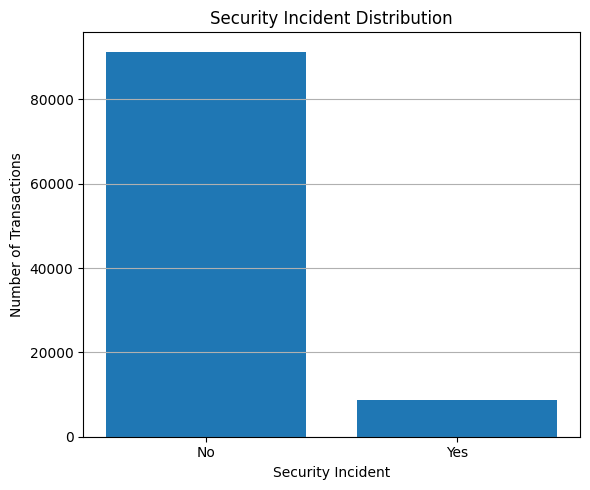

In [31]:
# ============================================================
# Chapter 14 - Security Incident Chart
# ============================================================

plt.figure(figsize=(6,5))

plt.bar(

    security_summary.index,

    security_summary.values

)

plt.title("Security Incident Distribution")

plt.xlabel("Security Incident")

plt.ylabel("Number of Transactions")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# Executive Performance Summary

Create a consolidated management report summarizing operational performance across all border posts.

This table is suitable for executive reporting and dashboard integration.

In [32]:
# ============================================================
# Chapter 15 - Executive Performance Summary
# ============================================================

executive_summary = (

    df.groupby("Border_Post")

    .agg(

        Total_Transactions=("Transaction_ID", "count"),

        Total_Revenue=("Revenue_Collected_USD", "sum"),

        Total_Trade_Value=("Trade_Value_USD", "sum"),

        Avg_Queue_Length=("Queue_Length", "mean"),

        Avg_Processing_Time=("Processing_Time_Minutes", "mean"),

        Avg_Efficiency=("Border_Efficiency_Score", "mean")

    )

    .round(2)

)

executive_summary

,Total_Transactions,Total_Revenue,Total_Trade_Value,Avg_Queue_Length,Avg_Processing_Time,Avg_Efficiency
Border_Post,,,,,,
Aflao,2612,18425257.09,1.405737e+08,22.57,44.31,83.19
Amdallai,3031,20662748.43,1.608466e+08,22.32,43.86,83.34
Bo Waterside,3540,24217075.11,1.897958e+08,22.73,44.71,83.09
Cinkanse,5504,37720302.83,2.903418e+08,22.55,44.34,83.21
Elubo,2706,18308650.53,1.433368e+08,22.70,44.27,83.25
Gaya,5338,37357217.26,2.867480e+08,22.50,44.14,83.30
Gbalamuya,3468,23821839.56,1.851335e+08,22.74,44.64,83.16
Gogui,5466,37039457.22,2.900902e+08,22.61,44.47,83.14
Hillacondji,6611,45471352.72,3.540514e+08,22.61,44.44,83.21


# Export Executive Reports

Export all executive reporting tables for use in Power BI, Streamlit dashboards, and future reporting activities.

In [33]:
# ============================================================
# Chapter 16 - Export Executive Reports
# ============================================================

kpi_summary.to_csv(

    "executive_kpi_summary.csv",

    index=False

)

executive_summary.to_csv(

    "executive_performance_summary.csv"

)

commodity_revenue.to_csv(

    "commodity_revenue_summary.csv",

    header=["Revenue_Collected_USD"]

)

revenue_border.to_csv(

    "border_revenue_summary.csv",

    header=["Revenue_Collected_USD"]

)

efficiency_rank.to_csv(

    "border_efficiency_ranking.csv",

    header=["Average_Efficiency"]

)

print("Executive reports exported successfully.")

Executive reports exported successfully.


# Verify Exported Reports

Verify that all executive reporting datasets have been successfully exported.

In [34]:
# ============================================================
# Chapter 17 - Verify Export
# ============================================================

import os

csv_files = sorted(

    [f for f in os.listdir()

     if f.endswith(".csv")]

)

print("Executive Report Files\n")

for file in csv_files:

    print(file)

Executive Report Files

border_efficiency_ranking.csv
border_revenue_summary.csv
commodity_revenue_summary.csv
executive_kpi_summary.csv
executive_performance_summary.csv
trade_diversion_transactions.csv


# Executive Insights

The analyses conducted in this notebook provide several important operational insights:

## Key Findings

- Customs revenue is concentrated among a relatively small number of border posts.
- Certain commodities contribute disproportionately to customs revenue.
- Operational efficiency varies across border locations.
- Inspection outcomes provide an indication of border compliance performance.
- Security incidents remain concentrated within specific operational environments.

## Business Recommendations

Based on the simulated analysis, border management agencies should consider:

1. Increasing staffing at high-revenue border posts.
2. Prioritizing inspection resources for high-risk commodities.
3. Improving processing efficiency at lower-performing border locations.
4. Strengthening security surveillance at borders with elevated incident levels.
5. Integrating predictive analytics into border intelligence systems to improve operational planning.

## Conclusion

Executive dashboards enable decision-makers to monitor border performance through concise performance indicators, improving strategic planning, operational efficiency, and evidence-based decision-making across the ECOWAS region.